# 08 — Softmax Gradients and Gradient Checking

The [previous notebook](./07_softmax_loss.ipynb) converted scores into probabilities and measured cross-entropy loss. We now derive how that loss changes with every score and model parameter.

## Learning objectives

- derive the compact score gradient $dS=(P-Y)/N$;
- interpret the gradient as predicted probability minus target probability;
- propagate score gradients to `W` and `b`;
- add the L2 regularization gradient using the project convention;
- verify analytic gradients numerically;
- compare gradient signals for confident, uncertain, and incorrect predictions.

In [13]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from torchvision.datasets import CIFAR10

SEED = 42
rng = np.random.default_rng(SEED)
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = PROJECT_ROOT / "data"

## 1. Derivative with respect to one score

We will consider **one training example**. Its model output is a vector of $C$ scores

$$s=[s_0,s_1,\ldots,s_{C-1}],$$

and $y$ is the index of the correct class. For example, $y=2$ means $s_y=s_2$. We want to know how a tiny change in each individual score $s_j$ changes the scalar loss:

$$d s_j=\frac{\partial L}{\partial s_j}.$$

This is a **partial derivative** because the loss depends on several scores. While differentiating with respect to $s_j$, all other scores are treated as constants.

### Step 1 — Rewrite the loss using scores

Softmax assigns the correct class probability

$$p_y=\frac{e^{s_y}}{\sum_k e^{s_k}}.$$

Cross-entropy is $L=-\log p_y$. Substitute the softmax expression:

$$L=-\log\left(\frac{e^{s_y}}{\sum_k e^{s_k}}\right).$$

Using $\log(a/b)=\log a-\log b$ and $\log(e^x)=x$ gives

$$L=-s_y+\log\left(\sum_k e^{s_k}\right).$$

This form has two parts: `-correct score` and `log of the exponential sum of all scores`.

### Step 2 — Derivative of the first part

Consider $-s_y$. Its derivative depends on whether $s_j$ is the correct score:

$$\frac{\partial(-s_y)}{\partial s_j}=
\begin{cases}
-1 & j=y,\\
0 & j\ne y.
\end{cases}$$

We can abbreviate these two cases with the indicator $\mathbb{1}[j=y]$, which equals `1` when $j=y$ and `0` otherwise:

$$\frac{\partial(-s_y)}{\partial s_j}=-\mathbb{1}[j=y].$$

### Step 3 — Derivative of the second part

Give the exponential sum a short name:

$$Z=\sum_k e^{s_k}.$$

The second part is $\log Z$. Apply the chain rule:

$$\frac{\partial\log Z}{\partial s_j}
=\frac{1}{Z}\frac{\partial Z}{\partial s_j}.$$

Inside $Z=e^{s_0}+e^{s_1}+\cdots+e^{s_j}+\cdots$, only $e^{s_j}$ changes with $s_j$. Because the derivative of $e^x$ is $e^x$,

$$\frac{\partial Z}{\partial s_j}=e^{s_j}.$$

Therefore,

$$\frac{\partial\log Z}{\partial s_j}
=\frac{e^{s_j}}{Z}
=\frac{e^{s_j}}{\sum_k e^{s_k}}
=p_j.$$

The derivative of the normalization term is exactly the softmax probability for class $j$.

### Step 4 — Add both derivative contributions

Since $L=-s_y+\log Z$, add the derivatives of its two parts:

$$\boxed{\frac{\partial L}{\partial s_j}=p_j-\mathbb{1}[j=y]}.$$

Written as separate cases, this is

$$\frac{\partial L}{\partial s_j}=
\begin{cases}
p_y-1 & j=y \quad\text{(correct class)},\\
p_j & j\ne y \quad\text{(incorrect class)}.
\end{cases}$$

For a three-class example whose correct class is `2`, the whole gradient vector is therefore

$$d s=[p_0,\ p_1,\ p_2-1].$$

Because $0<p_y<1$, the correct-class entry $p_y-1$ is negative. Incorrect-class entries $p_j$ are positive. Gradient descent **subtracts** this gradient, so it raises the correct score and lowers incorrect scores.

### Three derivative rules used above

$$\frac{d}{dx}e^x=e^x, \qquad
\frac{d}{dx}\log x=\frac{1}{x}, \qquad
\frac{d}{dx}f(g(x))=f'(g(x))g'(x).$$

### Exercise 1 — One score-gradient vector by hand

For probabilities `[0.09, 0.24, 0.67]` and correct class `2`:

1. calculate $p_j-\mathbb{1}[j=y]$ for every class;
2. state which score gradient is negative and why;
3. verify that the gradient entries sum to zero;
4. explain what gradient descent will do to each score.

Write your reasoning in a Markdown cell, then complete the vector below.

In [14]:
probabilities_one = np.array([0.09, 0.24, 0.67])
correct_label_one = 2

d_scores_one = np.array([p if i != correct_label_one else p - 1 for i, p in enumerate(probabilities_one)])

np.testing.assert_allclose(d_scores_one, np.array([0.09, 0.24, -0.33]))
assert np.isclose(d_scores_one.sum(), 0.0)
print(d_scores_one)

[ 0.09  0.24 -0.33]


### Why does the gradient sum to zero?

The probabilities sum to one, and a one-hot target also sums to one:

$$\sum_j(p_j-Y_j)=1-1=0.$$

This matches softmax's shift invariance. Adding the same constant to all scores changes neither probabilities nor loss, so the loss has no gradient in that shared-shift direction.

## 2. Vectorized batch score gradient

Section 1 considered one example. A batch contains $N$ examples and $C$ classes, so its score and probability matrices have shape `(N, C)`:

$$S=
\begin{bmatrix}
s_{00} & \cdots & s_{0,C-1}\\
\vdots & \ddots & \vdots\\
s_{N-1,0} & \cdots & s_{N-1,C-1}
\end{bmatrix},
\qquad
P=
\begin{bmatrix}
p_{00} & \cdots & p_{0,C-1}\\
\vdots & \ddots & \vdots\\
p_{N-1,0} & \cdots & p_{N-1,C-1}
\end{bmatrix}.$$

Row $i$ belongs to example $i$. Entry $p_{ij}$ is the probability assigned to class $j$ for that example. Softmax is applied independently to every row, so every row of $P$ sums to one.

### Step 1 — Represent labels as one-hot rows

The label array stores one correct-class index per example. For example, if

```text
labels = [0, 1]
```

for two examples and three classes, the corresponding one-hot target matrix is

$$Y=
\begin{bmatrix}
1&0&0\\
0&1&0
\end{bmatrix}.$$

Each row contains `1` at its correct class and `0` elsewhere. In notation, $Y_{ij}=\mathbb{1}[j=y_i]$.

### Step 2 — Apply the one-example result to every row

From Section 1, the unaveraged derivative for example $i$ and class $j$ is

$$\frac{\partial L_i}{\partial S_{ij}}=P_{ij}-Y_{ij}.$$

For the two-example target matrix above, this means

$$P-Y=
\begin{bmatrix}
p_{00}-1&p_{01}&p_{02}\\
p_{10}&p_{11}-1&p_{12}
\end{bmatrix}.$$

The subtraction of one occurs in a different column for each row because examples may have different correct classes.

### Step 3 — Account for the mean batch loss

Our batch data loss is the mean of its example losses:

$$L_{batch}=\frac{1}{N}\sum_{i=1}^{N}L_i.$$

The constant $1/N$ remains when differentiating, so every row gradient is divided by $N$:

$$\boxed{dS=\frac{P-Y}{N}}.$$

We divide by the number of examples $N$, not by the number of classes $C$, because the loss was averaged over examples. If the implementation summed example losses instead, this division would not appear.

### Step 4 — Translate the formula into NumPy

Constructing the full one-hot matrix is unnecessary. The formula can be implemented as

```python
d_scores = probabilities.copy()
d_scores[np.arange(N), labels] -= 1.0
d_scores /= N
```

`np.arange(N)` supplies row indices `[0, 1, ..., N-1]`, while `labels` supplies the correct column for each row. Paired advanced indexing therefore selects exactly `(0, labels[0])`, `(1, labels[1])`, and so on—the positions containing the ones in $Y$.

The `.copy()` is important. Starting with `d_scores = probabilities` would make both names refer to the same array, so subtracting one would corrupt the probabilities needed elsewhere. The returned `d_scores` still has shape `(N, C)`, but its entries are loss sensitivities, not probabilities.

### Exercise 2 — Implement the batch score gradient

In [15]:
def softmax_score_gradient(
    probabilities: np.ndarray, labels: np.ndarray
) -> np.ndarray:
    """Return the gradient of mean cross-entropy with respect to scores."""
    if probabilities.ndim != 2 or labels.ndim != 1:
        raise ValueError("Probabilities must be 2D and labels must be 1D.")
    if probabilities.shape[0] != labels.shape[0] or probabilities.shape[0] == 0:
        raise ValueError("Labels must match a nonempty probability batch.")
    if not np.issubdtype(labels.dtype, np.integer):
        raise TypeError("Labels must contain integers.")
    if np.any((labels < 0) | (labels >= probabilities.shape[1])):
        raise ValueError("Labels must be valid class indices.")

    # copy probabilities, subtract one at correct entries, and average.
    N = probabilities.shape[0]
    d_scores = probabilities.copy()
    d_scores[np.arange(N), labels] -= 1
    d_scores /= N
    return d_scores


probabilities_small = np.array([
    [0.70, 0.20, 0.10],
    [0.10, 0.30, 0.60],
])
labels_small = np.array([0, 1])
probabilities_before = probabilities_small.copy()
d_scores_small = softmax_score_gradient(probabilities_small, labels_small)
expected_d_scores = np.array([
    [-0.30, 0.20, 0.10],
    [0.10, -0.70, 0.60],
]) / 2

np.testing.assert_allclose(d_scores_small, expected_d_scores)
np.testing.assert_allclose(d_scores_small.sum(axis=1), 0.0, rtol=1e-05, atol=1e-08)
np.testing.assert_array_equal(probabilities_small, probabilities_before)
print(d_scores_small)

[[-0.15  0.1   0.05]
 [ 0.05 -0.35  0.3 ]]


## 3. From score gradients to parameter gradients

The linear score function is unchanged from the [SVM notebook](./06_svm_gradient_checking.ipynb):

$$S=XW^T+b.$$

Only the way we obtain $dS$ changes. Once $dS$ is known, the same chain-rule formulas apply:

$$dW=dS^TX, \qquad db=\sum_i dS_i.$$

With this project's regularization convention,

$$L_{reg}=\lambda\sum W^2, \qquad dW_{reg}=2\lambda W.$$

### Exercise 3 — Implement softmax loss and analytic gradients

Compute probabilities from shifted scores. For the loss, use the stable log-sum-exp expression directly rather than taking `log` of probabilities that might underflow to zero.

In [16]:
def softmax_loss_and_gradient(
    X: np.ndarray,
    y: np.ndarray,
    W: np.ndarray,
    b: np.ndarray,
    regularization_strength: float = 0.0,
) -> tuple[float, np.ndarray, np.ndarray]:
    """Return stable softmax loss and analytic gradients for W and b."""
    if X.ndim != 2 or W.ndim != 2:
        raise ValueError("X and W must be 2D arrays.")
    if y.ndim != 1 or b.ndim != 1:
        raise ValueError("y and b must be 1D arrays.")
    if X.shape[0] != y.shape[0] or X.shape[0] == 0:
        raise ValueError("X and y must contain the same nonzero number of examples.")
    if X.shape[1] != W.shape[1] or W.shape[0] != b.shape[0]:
        raise ValueError("Feature and class dimensions do not match.")
    if not np.issubdtype(y.dtype, np.integer):
        raise TypeError("Labels must contain integers.")
    if np.any((y < 0) | (y >= W.shape[0])):
        raise ValueError("Labels must be valid class indices.")
    if regularization_strength < 0:
        raise ValueError("Regularization strength must be nonnegative.")

    # scores, shifted scores, exponentials, and probabilities.
    scores = X @ W.T + b
    shifted_scores = scores - np.max(scores, axis=1, keepdims=True)
    exp_scores = np.exp(shifted_scores)
    sum_exp_scores = np.sum(exp_scores, axis=1, keepdims=True)
    probabilities = exp_scores / sum_exp_scores
    log_sum_exp = np.log(sum_exp_scores[:, 0])
    correct_class_scores = shifted_scores[np.arange(scores.shape[0]), y]
    # mean data loss plus L2 regularization loss.
    data_loss = np.mean(log_sum_exp - correct_class_scores)
    reg_loss = regularization_strength * np.sum(W * W)
    loss = data_loss + reg_loss
    # d_scores, dW including regularization, and db.
    d_scores = softmax_score_gradient(probabilities, y)
    dW = d_scores.T @ X + 2 * regularization_strength * W
    db = d_scores.sum(axis=0)

    return loss, dW, db


X_tiny = np.array([[1.0, -2.0], [0.5, 1.5], [-1.0, 2.0]])
y_tiny = np.array([0, 0, 0])
W_tiny = rng.normal(0.0, 0.1, size=(3, 2))
b_tiny = rng.normal(0.0, 0.1, size=3)

loss_tiny, dW_tiny, db_tiny = softmax_loss_and_gradient(
    X_tiny, y_tiny, W_tiny, b_tiny, regularization_strength=0.1
)
assert np.ndim(loss_tiny) == 0
assert dW_tiny.shape == W_tiny.shape
assert db_tiny.shape == b_tiny.shape
print("Loss:", loss_tiny)
print("dW:\n", dW_tiny)
print("db:", db_tiny)

Loss: 1.118235002162011
dW:
 [[-0.06904244 -0.44039926]
 [ 0.04572094  0.30422726]
 [ 0.00540416  0.10814002]]
db: [-0.66699919  0.35672761  0.31027159]


## 4. Numerical gradient checking

We already developed centered differences in [notebook 06](./06_svm_gradient_checking.ipynb), so the helpers are provided here. Recall that numerical checking is slow and approximate; its purpose is to test the analytic implementation on a small deterministic problem.

In [17]:
def numerical_gradient(
    loss_function, parameter: np.ndarray, h: float = 1e-5
) -> np.ndarray:
    """Estimate all coordinates of a scalar loss gradient."""
    gradient = np.zeros_like(parameter, dtype=np.float64)
    for index in np.ndindex(parameter.shape):
        original = parameter[index]
        parameter[index] = original + h
        loss_plus = loss_function()
        parameter[index] = original - h
        loss_minus = loss_function()
        parameter[index] = original
        gradient[index] = (loss_plus - loss_minus) / (2 * h)
    return gradient


def max_relative_error(analytic: np.ndarray, numerical: np.ndarray) -> float:
    denominator = np.maximum(1e-8, np.abs(analytic) + np.abs(numerical))
    return float(np.max(np.abs(analytic - numerical) / denominator))

### Exercise 4 — Check `dW` and `db`

Create a zero-argument loss function that closes over the current `W_tiny` and `b_tiny`. Numerically check both parameter arrays and report their maximum relative errors.

In [18]:
regularization_strength = 0.1
loss_tiny, dW_tiny, db_tiny = softmax_loss_and_gradient(
    X_tiny, y_tiny, W_tiny, b_tiny, regularization_strength
)

# define loss_from_current_parameters.
loss_from_current_parameters = lambda: softmax_loss_and_gradient(
    X_tiny, y_tiny, W_tiny, b_tiny, regularization_strength
)[0]
# compute numerical gradients and relative errors.
dW_numerical = numerical_gradient(loss_from_current_parameters, W_tiny)
db_numerical = numerical_gradient(loss_from_current_parameters, b_tiny)
W_error = max_relative_error(dW_tiny, dW_numerical)
b_error = max_relative_error(db_tiny, db_numerical)

print(f"W maximum relative error: {W_error:.3e}")
print(f"b maximum relative error: {b_error:.3e}")
assert W_error < 1e-6
assert b_error < 1e-6

W maximum relative error: 5.189e-10
b maximum relative error: 1.331e-11


In [19]:
dW_numerical, dW_tiny

(array([[-0.06904244, -0.44039926],
        [ 0.04572094,  0.30422726],
        [ 0.00540416,  0.10814002]]),
 array([[-0.06904244, -0.44039926],
        [ 0.04572094,  0.30422726],
        [ 0.00540416,  0.10814002]]))

## 5. Interpreting `probabilities - targets`

The gradient magnitude automatically reflects confidence:

- for the correct class, $p_y-1$ is strongly negative when the model assigns low probability to the truth;
- for an incorrect class, $p_j$ is strongly positive when the model assigns it too much probability;
- when $p_y$ is near one, every score gradient is near zero.

Gradient descent subtracts the gradient, so it raises the correct score and lowers incorrect scores.

### Exercise 5 — Compare confidence cases

Class `0` is correct in all three rows below. Calculate their probabilities, score gradients, and losses. Explain why the confidently wrong example creates the strongest corrective signal and the confidently correct example creates the weakest.

In [20]:
confidence_scores = np.array([
    [5.0, 0.0, 0.0],   # confidently correct
    [0.0, 0.0, 0.0],   # uncertain
    [-5.0, 5.0, 0.0],  # confidently wrong
])
confidence_labels = np.array([0, 0, 0])

# compute stable probabilities.
shifted_confidence_scores = confidence_scores - np.max(
    confidence_scores, axis=1, keepdims=True
)
exp_scores = np.exp(shifted_confidence_scores)
sum_exp_scores = np.sum(exp_scores, axis=1, keepdims=True)
confidence_probabilities = exp_scores / sum_exp_scores
# Do not average here: we want each example's individual gradient signal.
confidence_gradients = confidence_probabilities.copy()
confidence_gradients[np.arange(3), confidence_labels] -= 1.0
# compute the three individual stable cross-entropy losses.
log_sum_exp = np.log(sum_exp_scores[:, 0])
correct_class_scores = shifted_confidence_scores[
    np.arange(confidence_scores.shape[0]), confidence_labels
]
confidence_losses = log_sum_exp - correct_class_scores
gradient_magnitudes = np.linalg.norm(confidence_gradients, axis=1)

assert np.all(np.diff(confidence_losses) > 0)
assert np.all(np.diff(gradient_magnitudes) > 0)

for name, probabilities, gradient, loss in zip(
    ["confidently correct", "uncertain", "confidently wrong"],
    confidence_probabilities, confidence_gradients, confidence_losses,
):
    print(f"{name:20s} p={probabilities}, dS={gradient}, loss={loss:.4f}")

confidently correct  p=[0.98670329 0.00664835 0.00664835], dS=[-0.01329671  0.00664835  0.00664835], loss=0.0134
uncertain            p=[0.33333333 0.33333333 0.33333333], dS=[-0.66666667  0.33333333  0.33333333], loss=1.0986
confidently wrong    p=[4.50940412e-05 9.93262357e-01 6.69254912e-03], dS=[-0.99995491  0.99326236  0.00669255], loss=10.0068


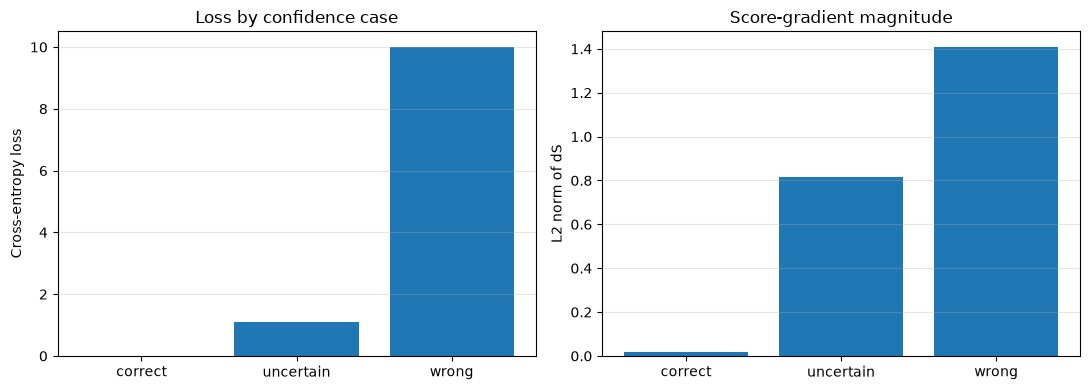

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
case_names = ["correct", "uncertain", "wrong"]
axes[0].bar(case_names, confidence_losses)
axes[0].set(title="Loss by confidence case", ylabel="Cross-entropy loss")
axes[1].bar(case_names, gradient_magnitudes)
axes[1].set(title="Score-gradient magnitude", ylabel="L2 norm of dS")
for ax in axes:
    ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
plt.show()

### Interpreting the three cases

For the confidently correct example, $p_y\approx0.987$, so the correct-class gradient $p_y-1\approx-0.013$ is already close to zero. The model needs only a small adjustment.

For the uncertain example, every class has probability $1/3$. The correct score receives gradient $-2/3$, while each incorrect score receives $+1/3$. This creates a moderate correction.

For the confidently wrong example, the correct class receives almost zero probability. Its gradient is therefore nearly $-1$, while the incorrectly favored class has gradient nearly $+1$. When gradient descent subtracts these values, it strongly raises the correct score and lowers the favored incorrect score.

The loss can grow without bound as the correct-class probability approaches zero, but each individual score-gradient entry remains between `-1` and `1`. Confidence controls how close the gradient gets to those limits.

## 6. Sparse check on CIFAR-10

A full numerical check of a `(10, 3072)` weight matrix is unnecessarily expensive. We will compute the full analytic gradient and numerically check only selected coordinates.

In [25]:
dataset = CIFAR10(root=DATA_DIR, train=True, download=True)
batch_indices = rng.choice(len(dataset.data), size=8, replace=False)
X_cifar = dataset.data[batch_indices].reshape(8, -1).astype(np.float64) / 255.0
X_cifar -= X_cifar.mean(axis=0, keepdims=True)
y_cifar = np.asarray(dataset.targets, dtype=np.int64)[batch_indices]
W_cifar = rng.normal(0.0, 1e-3, size=(10, X_cifar.shape[1]))
b_cifar = np.zeros(10, dtype=np.float64)
cifar_regularization_strength = 1e-3

cifar_loss, dW_cifar, db_cifar = softmax_loss_and_gradient(
    X_cifar, y_cifar, W_cifar, b_cifar, cifar_regularization_strength
)
print("Tiny-batch loss:", cifar_loss)
print("Expected near log(10):", np.log(10))
print("Gradient shapes:", dW_cifar.shape, db_cifar.shape)

Tiny-batch loss: 2.300802344823938
Expected near log(10): 2.302585092994046
Gradient shapes: (10, 3072) (10,)


In [26]:
def numerical_gradient_at_coordinate(
    loss_function, parameter: np.ndarray, index: tuple[int, ...], h: float = 1e-5
) -> float:
    original = parameter[index]
    parameter[index] = original + h
    loss_plus = loss_function()
    parameter[index] = original - h
    loss_minus = loss_function()
    parameter[index] = original
    return float((loss_plus - loss_minus) / (2 * h))


### Exercise 6 — Check selected CIFAR-10 coordinates

Define a zero-argument CIFAR loss function and check ten random weight coordinates. Print analytic gradient, numerical gradient, absolute error, and relative error. Near-zero gradients can have a noticeable relative error despite a tiny absolute error.

In [27]:
# define cifar_loss_function using the current CIFAR parameters.
cifar_loss_function = lambda: softmax_loss_and_gradient(
    X_cifar, y_cifar, W_cifar, b_cifar, cifar_regularization_strength
)[0]

flat_indices = rng.choice(W_cifar.size, size=10, replace=False)
coordinate_relative_errors = []
for flat_index in flat_indices:
    index = np.unravel_index(flat_index, W_cifar.shape)
    numerical = numerical_gradient_at_coordinate(
        cifar_loss_function, W_cifar, index
    )
    analytic = dW_cifar[index]
    absolute = abs(analytic - numerical)
    relative = absolute / max(1e-8, abs(analytic) + abs(numerical))
    coordinate_relative_errors.append(relative)
    print(
        f"W{index}: analytic={analytic:+.7e}, numerical={numerical:+.7e}, "
        f"absolute={absolute:.3e}, relative={relative:.3e}"
    )

assert max(coordinate_relative_errors) < 1e-5

W(np.int64(1), np.int64(2776)): analytic=-6.3251774e-02, numerical=-6.3251774e-02, absolute=2.384e-11, relative=1.884e-10
W(np.int64(7), np.int64(2432)): analytic=-8.6155703e-03, numerical=-8.6155703e-03, absolute=1.532e-11, relative=8.891e-10
W(np.int64(8), np.int64(2065)): analytic=-1.5064704e-04, numerical=-1.5064703e-04, absolute=8.625e-12, relative=2.863e-08
W(np.int64(8), np.int64(750)): analytic=-7.6604934e-05, numerical=-7.6604922e-05, absolute=1.130e-11, relative=7.376e-08
W(np.int64(1), np.int64(292)): analytic=-1.1185052e-01, numerical=-1.1185052e-01, absolute=9.602e-12, relative=4.292e-11
W(np.int64(2), np.int64(12)): analytic=-2.0929669e-04, numerical=-2.0929667e-04, absolute=1.775e-11, relative=4.241e-08
W(np.int64(9), np.int64(33)): analytic=-4.7263594e-02, numerical=-4.7263594e-02, absolute=4.703e-11, relative=4.976e-10
W(np.int64(6), np.int64(235)): analytic=+8.9036806e-02, numerical=+8.9036806e-02, absolute=1.090e-11, relative=6.123e-11
W(np.int64(6), np.int64(2912)):

## Reflection

Add a Markdown cell answering:

1. Starting from $-s_y+\log\sum_k e^{s_k}$, where do the two terms in $p_j-\mathbb{1}[j=y]$ come from?
2. Why is the correct-class score gradient negative?
3. Why are incorrect-class score gradients positive?
4. Why does each row of the score gradient sum to zero?
5. Why do SVM and softmax have different `d_scores` but identical formulas for `dW` and `db` afterward?
6. Why does a confidently wrong prediction create a larger corrective signal than a confidently correct prediction?
7. Where does averaging over batch size enter the gradient?
8. What does L2 regularization add to the loss and to `dW`?
9. What evidence would convince you that an analytic gradient implementation is correct?

Next we will use these gradients to train a linear classifier with stochastic gradient descent.

1. p is derivative by score of second part and -1[j=y] is derivative of first part. Differentiating \(-s_y\) gives \(-\mathbb{1}[j=y]\). Differentiating the log-sum-exp term gives \(p_j\).
2. For the correct class derivative equals p-1 and p always less than 1. For finite scores, \(0<p_y<1\), so this is negative. Gradient descent subtracts the negative gradient and therefore raises the correct score.
3. For an incorrect class \(j\) derivative is simply p which is in range 0-1. Gradient descent subtracts this positive value, lowering that incorrect score. An incorrect class receiving more probability gets a larger downward correction.
4. Sum of all probabilities is 1 and for positive class we have derivative equal p-1 which means sum will become 1-1=0. Division by \(N\) does not change that zero row sum. This also reflects softmax’s invariance to adding the same constant to every score.
5. SVM and softmax produce different d_scores because they use different loss functions. But both use the same score function:
$
S=XW^T+b.
$. Once either loss provides \(dS\), the remaining computational graph is identical. Applying the same chain rule gives: $dW=dS^TX,
\qquad
db=\sum_i dS_i.$ . So the upstream loss derivative differs, while the downstream parameter transformation is shared.
6. In formula we have p-1 in case of correct prediction which become close to 0 and for wrong prediction it is simply p. The correct-class derivative is always \(p_y-1\), whether the prediction is right or wrong. For a confidently correct prediction:
$p_y\approx1
\quad\Rightarrow\quad
p_y-1\approx0.$
Incorrect probabilities are also near zero, so all gradient entries are small.
For a confidently wrong prediction:
$p_y\approx0
\quad\Rightarrow\quad
p_y-1\approx-1.$
The favored incorrect class may have \(p_j\approx1\), giving it a gradient near \(+1\). Gradient descent therefore strongly raises the correct score and strongly lowers the incorrectly favored score.
7. it is divided by samples amount N. Batch loss is a mean:
$
L_{\text{batch}}=\frac1N\sum_i L_i,
$
the score gradient is:
$
dS=\frac{P-Y}{N}.
$
That averaging is already included before calculating dW and db, so it propagates into both.
8. $L_{\text{total}}
=
L_{\text{data}}+\lambda\sum W^2$
$dW=dW_{\text{data}}+2\lambda W.$
9. it matches numerical one. Strong evidence includes:
- very small relative error across multiple W and b coordinates;
- checks on several random inputs and parameter values;
- float64 calculations;
- deterministic loss evaluations;
- agreement on both tiny synthetic data and selected CIFAR-10 coordinates;
- expected shape and invariance checks.